In [1]:
from netCDF4 import Dataset
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import pdb
import os
import matplotlib.gridspec as gridspec

In [2]:
def experiments(replace,date,var1,var2):
    ### Original data
    data = pd.read_csv(path+'Data_to_train.csv', parse_dates = True, index_col = 0)
    dat_p = data.loc['2017-03-15':'2017-05-15']
    dat = dat_p
    ### Lets try to produce only reversals and only organise convection
    apr12 = dat_p.loc[date]
    ### Change the advection of moisture completely
    if var1 == None and var2 == None:
        for i in replace:
            dat[i] = apr12[i]
    elif var2 == None:
        for i in replace:
            dat[i] = apr12[var1]
    else:
        count = 0
        for i in replace:
            if count < 7: 
                dat[i] = apr12[var1]
                count = count + 1
            else:
                dat[i] = apr12[var2]
                count = count + 1
    ### Prediction
    Xvals = dat[0:int(len(dat)*1)][['SST','IQR','TCWV','LW','W0','W1','W7','U0','U1','U4','U7','U11','U14','U26',
                                    'V0','V1','V4','V7','V9','V12','V14','V26']].values
    predic = NN_model.predict(Xvals) 
    return(predic)

# Now we have the data ready!

In [3]:
###Read Datasets and convert them!
#Path
latitud = '2-9'
longitud = '135-145'
path = '/Users/acasalla/Documents/PhD/Thesis/NN_real/Area_'+latitud+'_'+longitud+'_ERA5/'
#Data
Y = pd.read_csv(path+'Slopes_data_ERA5.csv')
X = pd.read_csv(path+'Data_to_train.csv')
X = X[X.columns[1:]]
Y = pd.DataFrame({'Slope':np.array(Y['Slope'])})

In [4]:
y_all = Y['Slope'].values
X_all = X.copy()
# Compute thresholds
mean_slope = np.mean(y_all)
std_slope = np.std(y_all)
high_thresh = mean_slope + 1.0 * std_slope
low_thresh = mean_slope - 1.0 * std_slope

print(f"Mean Slope: {mean_slope:.4f}")
print(f"Std Slope: {std_slope:.4f}")
print(f"High γ ≥ {high_thresh:.4f}")
print(f"Low γ <  {low_thresh:.4f}")

print(f"----------------o----------------")

high_mask = y_all >= high_thresh
low_mask = y_all < low_thresh

X_high = X_all.loc[high_mask]
X_low  = X_all.loc[low_mask]
print(f"High slope cases: {X_high.shape[0]}")
print(f"Low slope cases : {X_low.shape[0]}")

Mean Slope: 0.0012
Std Slope: 0.0044
High γ ≥ 0.0056
Low γ <  -0.0032
----------------o----------------
High slope cases: 4845
Low slope cases : 4218


# Training!

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=1, test_size=0.2)
#X_train = X[:int(len(X)*0.8)]; X_test = X[int(len(X)*0.8):]; y_train = Y[:int(len(Y)*0.8)]
#y_test = Y[int(len(Y)*0.8):]
#X_train = X[0:int(len(X)*1)][['SST','TCWV','LW','W0','W1','W7','U0','U1','U4','U7','U11','U14','U26','V0','V1',
#                              'V4','V7','V9','V12','V14','V26']].values
#y_train = Y[0:int(len(Y)*1)][['Slope']].values

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
### Random Forest
NN_model = RandomForestRegressor()
NN_model.fit(X_train, y_train)
#
### Neural Network
#
#nn = 64
#NN_model = MLPRegressor(hidden_layer_sizes=(nn,nn,nn,nn,nn),activation="relu")
#NN_model.fit(X_train, y_train)
##
### Decision Tree
#
#NN_model = DecisionTreeRegressor()
#NN_model.fit(X_train, y_train)
##
### SVM
#
#NN_model = SVR(kernel='rbf', C = 10**5, gamma = 0.1)
#NN_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [7]:
print(NN_model.get_params())
print(X.shape)

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
(35040, 22)


In [8]:
# Save feature rankings
def save_shap_ranking(shap_vals, X_subset, filename):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    shap_rank = pd.DataFrame({
        "feature": X_subset.columns,
        "mean_abs_SHAP": mean_abs
    }).sort_values(by="mean_abs_SHAP", ascending=False)
    shap_rank.to_csv(filename, index=False)
    
def compute_shap_in_batches(explainer, X, batch_size=500):
    shap_values = []
    for i in range(0, len(X), batch_size):
        print(f"Computing SHAP for rows {i} to {min(i+batch_size, len(X)) - 1}")
        batch = X.iloc[i:i+batch_size]
        shap_values_batch = explainer.shap_values(batch)
        shap_values.append(shap_values_batch)
    return np.vstack(shap_values)

In [9]:
if os.path.exists(f"{path}shap_ranking_{latitud}_{longitud}_high1.csv"):
    shap_vals_high = pd.read_csv(f"{path}shap_ranking_{latitud}_{longitud}_high.csv", index_col = 0)
    shap_vals_low = pd.read_csv(f"{path}shap_ranking_{latitud}_{longitud}_low.csv", index_col = 0)
else:
    # SHAP values
    pdb.set_trace()
    X_high_sample = X_high.sample(n=1000, random_state=0) if len(X_high) > 1000 else X_high
    X_low_sample  = X_low.sample(n=1000, random_state=0) if len(X_low) > 1000 else X_low
    explainer = shap.TreeExplainer(NN_model)
    print('High Slope values')
    shap_vals_high = compute_shap_in_batches(explainer, X_high_sample, batch_size=500)
    #shap_vals_high = compute_shap_in_batches(explainer, X_high, batch_size=500)
    print('Low Slope values')
    shap_vals_low = compute_shap_in_batches(explainer, X_low_sample, batch_size=500)  
    #shap_vals_low = compute_shap_in_batches(explainer, X_low, batch_size=500)
    
    #save_shap_ranking(shap_vals_high, X_high_sample, f"{path}shap_ranking_{latitud}_{longitud}_high.csv")
    #save_shap_ranking(shap_vals_low, X_low_sample, f"{path}shap_ranking_{latitud}_{longitud}_low.csv")

> /var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/2813992942.py(7)<module>()
      5     # SHAP values
      6     pdb.set_trace()
----> 7     X_high_sample = X_high.sample(n=1000, random_state=0) if len(X_high) > 1000 else X_high
      8     X_low_sample  = X_low.sample(n=1000, random_state=0) if len(X_low) > 1000 else X_low
      9     explainer = shap.TreeExplainer(NN_model)

ipdb> n
> /var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/2813992942.py(8)<module>()
      6     pdb.set_trace()
      7     X_high_sample = X_high.sample(n=1000, random_state=0) if len(X_high) > 1000 else X_high
----> 8     X_low_sample  = X_low.sample(n=1000, random_state=0) if len(X_low) > 1000 else X_low
      9     explainer = shap.TreeExplainer(NN_model)
     10     print('High Slope values')

ipdb> n
> /var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/2813992942.py(9)<module>()
      7     X_high_sample = X_high.sample(n=1000, random_state=0) if len(X_high

ipdb> c


=== SHAP Summary: High Slope ===


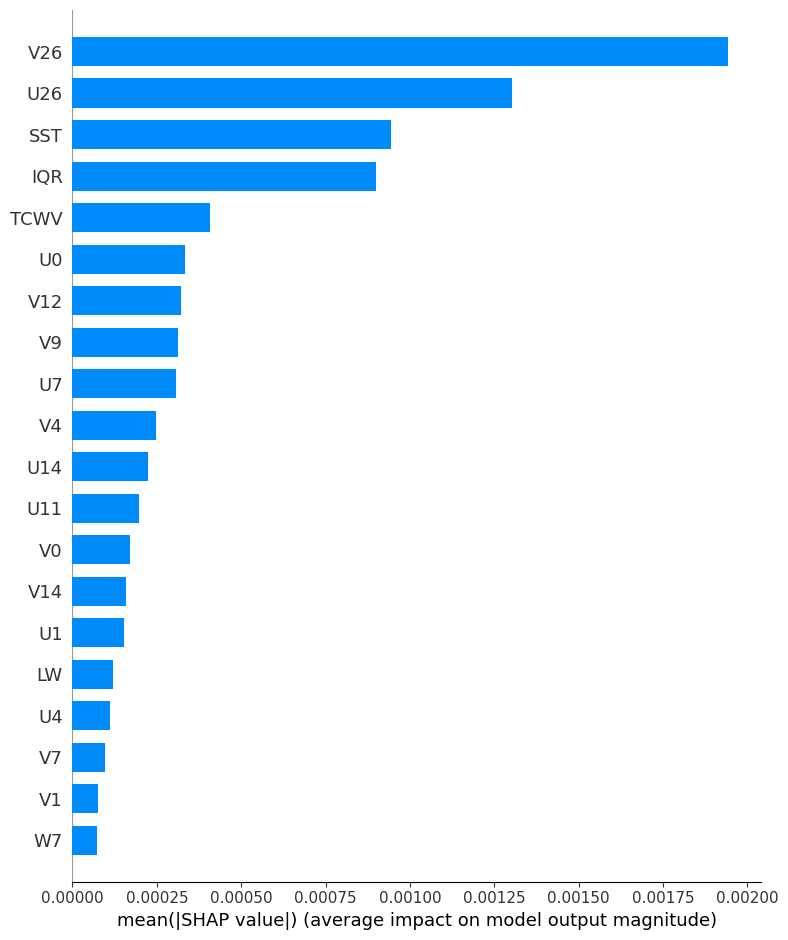

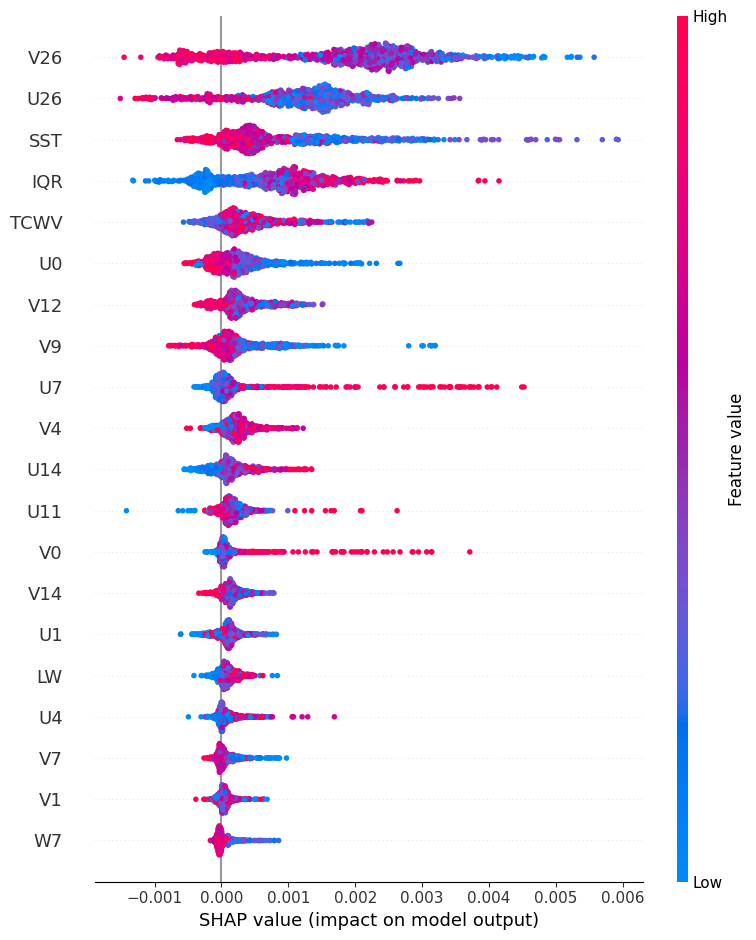

=== SHAP Summary: Low Slope ===


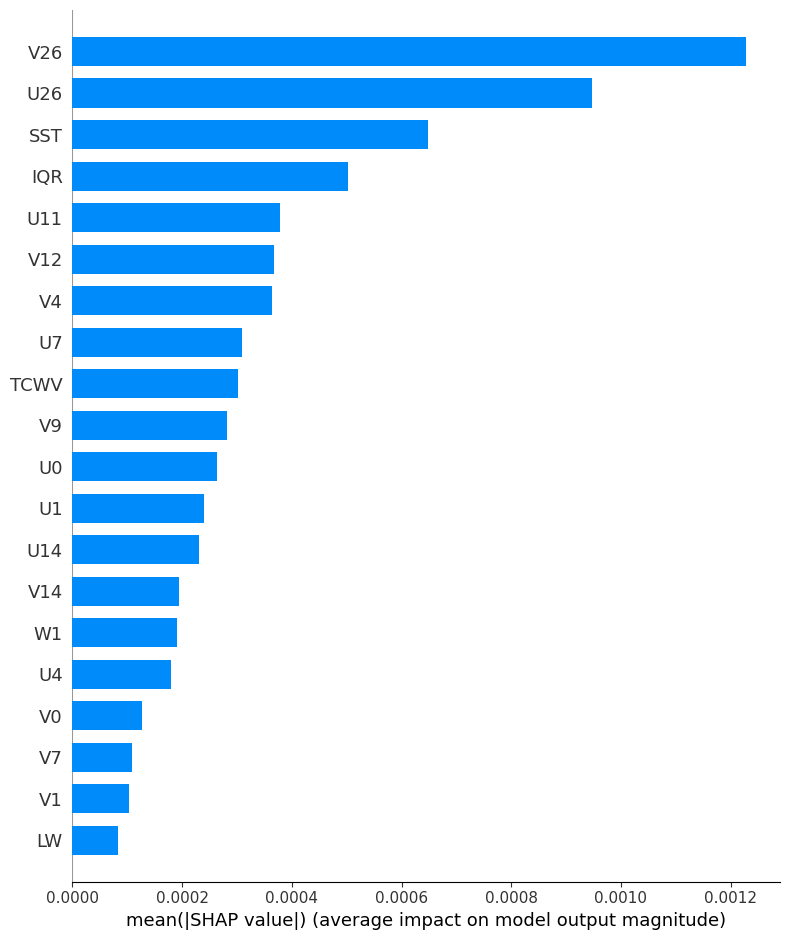

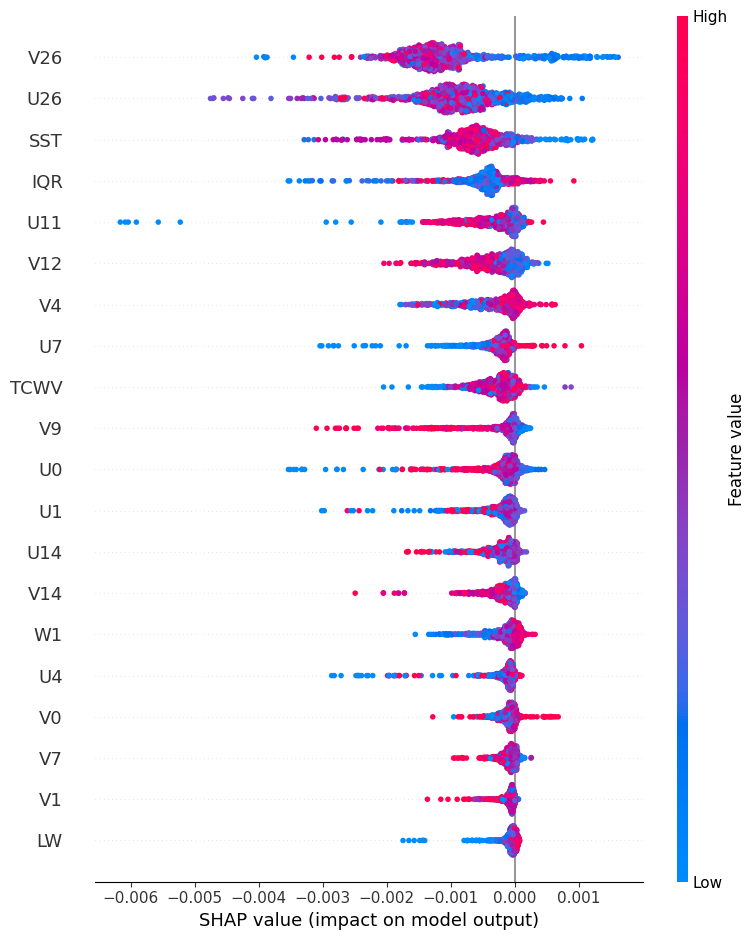

In [11]:
# High-slope summary
print("=== SHAP Summary: High Slope ===")
shap.summary_plot(shap_vals_high, X_high_sample, plot_type='bar')  # Bar plot
shap.summary_plot(shap_vals_high, X_high_sample)                   # Beeswarm plot

# Low-slope summary
print("=== SHAP Summary: Low Slope ===")
shap.summary_plot(shap_vals_low, X_low_sample, plot_type='bar')    # Bar plot
shap.summary_plot(shap_vals_low, X_low_sample)     

=== SHAP Summary: High Slope (IQR removed) ===


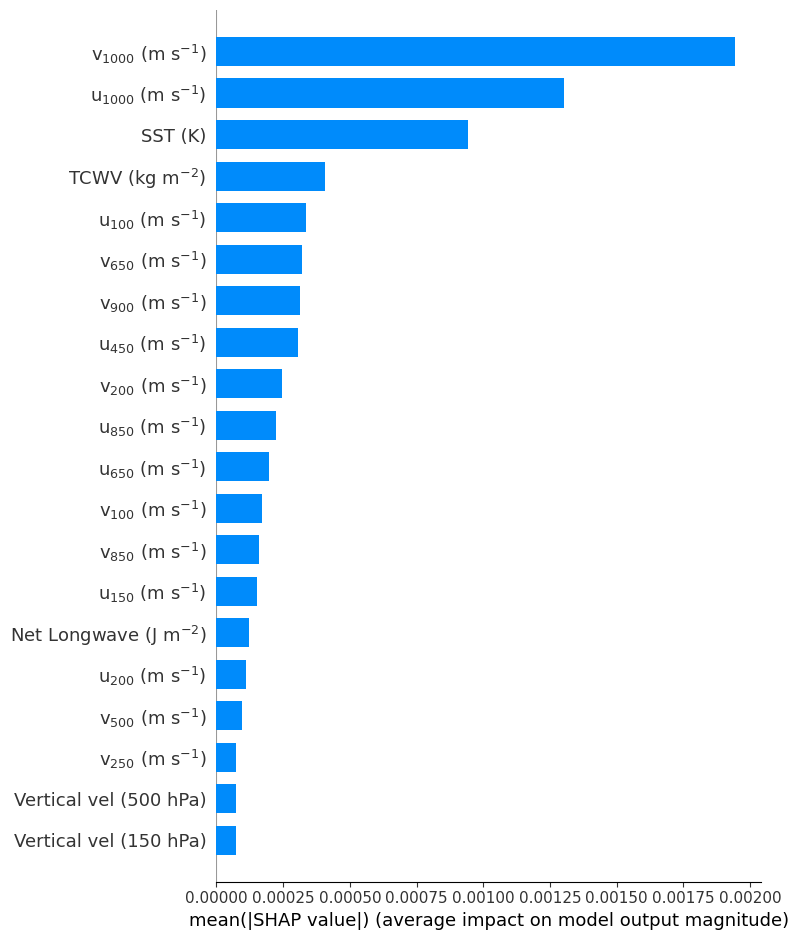

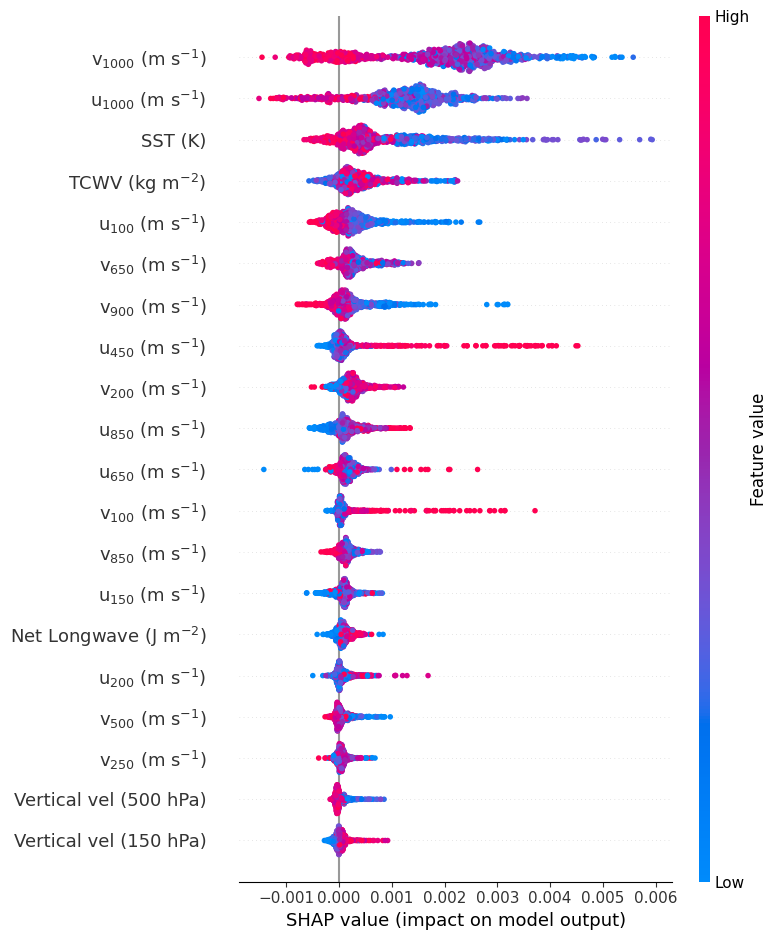

=== SHAP Summary: Low Slope (IQR removed) ===


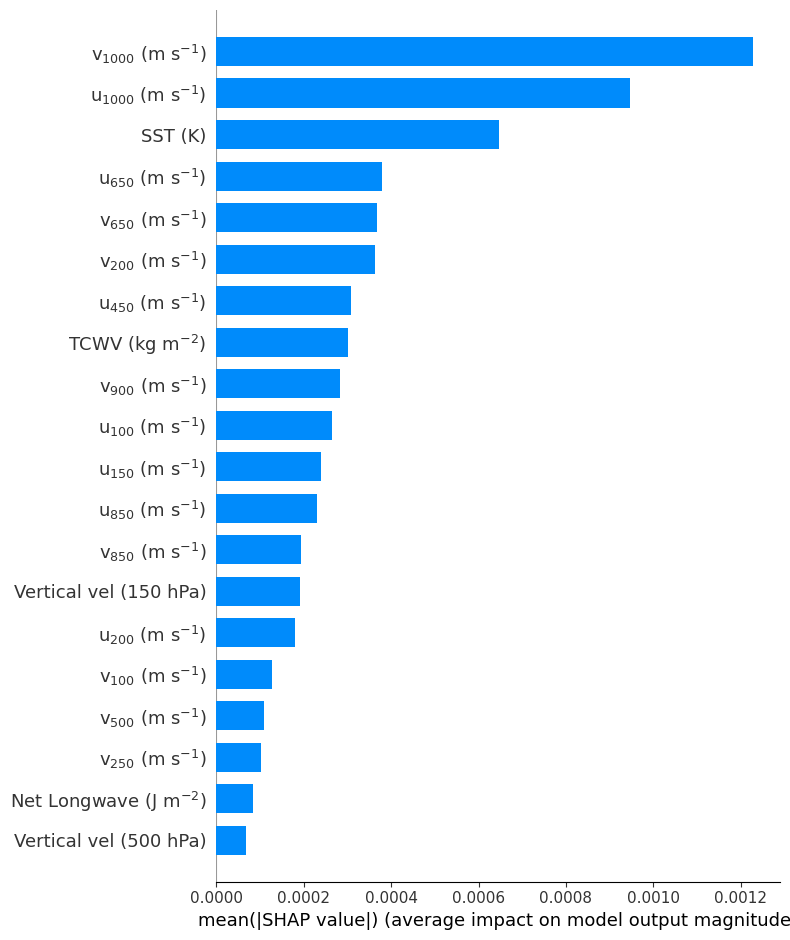

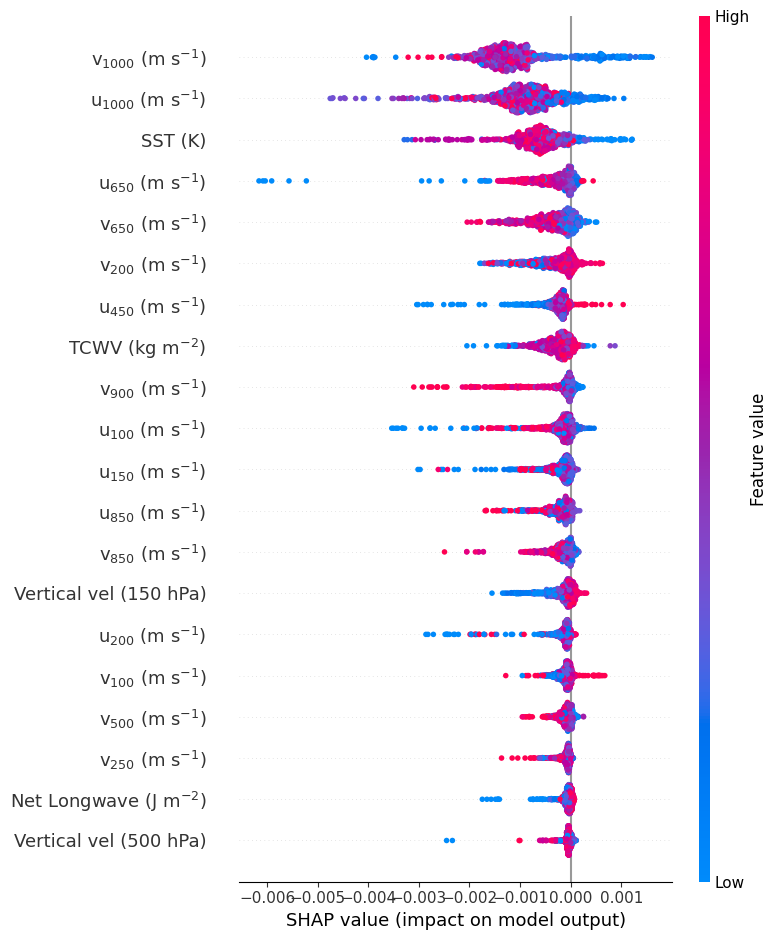

In [16]:
# -------- 1) Configure what to drop + how to rename --------
FEATURE_TO_EXCLUDE = "IQR"

# Fill in what makes sense for your variables
RENAME_MAP = {
    "U26": "u$_{1000}$ (m s$^{-1}$)",
    "V26": "v$_{1000}$ (m s$^{-1}$)",
    "U14": "u$_{850}$ (m s$^{-1}$)",
    "V14": "v$_{850}$ (m s$^{-1}$)",
    "U11": "u$_{650}$ (m s$^{-1}$)",
    "V12": "v$_{650}$ (m s$^{-1}$)",
    "U7":  "u$_{450}$ (m s$^{-1}$)",
    "U4":  "u$_{200}$ (m s$^{-1}$)",
    "U1":  "u$_{150}$ (m s$^{-1}$)",
    "U0":  "u$_{100}$ (m s$^{-1}$)",
    "V9":  "v$_{900}$ (m s$^{-1}$)",
    "V7":  "v$_{500}$ (m s$^{-1}$)",
    "V4":  "v$_{200}$ (m s$^{-1}$)",
    "V1":  "v$_{250}$ (m s$^{-1}$)",
    "V0":  "v$_{100}$ (m s$^{-1}$)",
    "W7":  "Vertical vel (500 hPa)",
    "W1":  "Vertical vel (150 hPa)",
    "W0":  "Vertical vel (100 hPa)",
    "SST": "SST (K)",
    "TCWV":"TCWV (kg m$^{-2}$)",
    "LW":  "Net Longwave (J m$^{-2}$)",
    # "IQR": "TCWV IQR"   # excluded below, so no need to rename
}

# -------- 2) Helper to align SHAP array with dropped/renamed columns --------
import numpy as np
import pandas as pd

def prepare_for_plot(X_subset: pd.DataFrame, shap_vals: np.ndarray,
                     drop_feature: str | None, rename_map: dict):
    cols = list(X_subset.columns)
    shap_plot = shap_vals
    X_plot = X_subset.copy()

    if drop_feature in cols:
        idx = cols.index(drop_feature)
        # drop column from X for plotting
        X_plot = X_plot.drop(columns=[drop_feature])
        # drop corresponding column from SHAP values
        shap_plot = np.delete(shap_plot, idx, axis=1)
        cols.pop(idx)

    # rename columns (only affects plot labels)
    X_plot = X_plot.rename(columns={k: v for k, v in rename_map.items() if k in X_plot.columns})
    return X_plot, shap_plot

# -------- 3) Build plotting datasets (high / low) --------
X_high_plot, shap_high_plot = prepare_for_plot(X_high_sample, shap_vals_high,
                                               FEATURE_TO_EXCLUDE, RENAME_MAP)
X_low_plot,  shap_low_plot  = prepare_for_plot(X_low_sample,  shap_vals_low,
                                               FEATURE_TO_EXCLUDE, RENAME_MAP)

# -------- 4) Plots --------
print("=== SHAP Summary: High Slope (IQR removed) ===")
shap.summary_plot(shap_high_plot, X_high_plot, plot_type='bar')
shap.summary_plot(shap_high_plot, X_high_plot)

print("=== SHAP Summary: Low Slope (IQR removed) ===")
shap.summary_plot(shap_low_plot, X_low_plot, plot_type='bar')
shap.summary_plot(shap_low_plot, X_low_plot)

/opt/anaconda3/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/anaconda3/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/4161362111.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


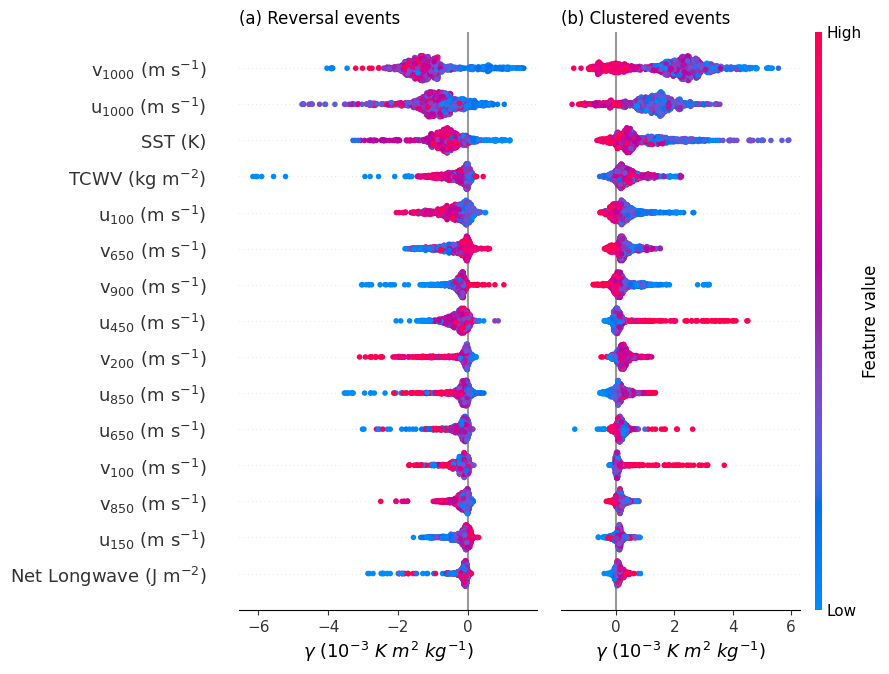

In [17]:
# --- ensure same feature order in both panels (here: by mean |SHAP| on high-γ) ---
MAX_DISPLAY = 15
mean_abs = np.abs(shap_high_plot).mean(axis=0)
order = np.argsort(-mean_abs)

X_low_cmp   = X_low_plot.iloc[:,  order]
X_high_cmp  = X_high_plot.iloc[:, order]
shap_low_cmp  = shap_low_plot[:,  order]
shap_high_cmp = shap_high_plot[:, order]

# --- scale SHAP values by 1000 for the x-axis ---
SCALE = 1000.0
shap_low_scaled  = shap_low_cmp  * SCALE
shap_high_scaled = shap_high_cmp * SCALE

# --- figure with GridSpec split panels ---
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[1, 1], wspace=0.08)

ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1], sharey=ax_left)  # share y so feature rows align

# (a) Low-γ panel (no colorbar)
plt.sca(ax_left)
shap.summary_plot(
    shap_low_scaled, X_low_cmp,
    plot_type="dot",
    show=False,
    color_bar=False,
    max_display=MAX_DISPLAY
)
ax_left.set_title("(a) Reversal events", loc = 'left')
ax_left.margins(x=0.05)
plt.xlabel('$\gamma$ (10$^{-3}$ $K$ $m^2$ $kg^{-1}$)')


# (b) High-γ panel (single colorbar)
plt.sca(ax_right)
shap.summary_plot(
    shap_high_scaled, X_high_cmp,
    plot_type="dot",
    show=False,
    color_bar=True,           # only one colorbar on the right
    max_display=MAX_DISPLAY
)
ax_right.set_title("(b) Clustered events", loc = 'left')
ax_right.margins(x=0.05)
plt.xlabel('$\gamma$ (10$^{-3}$ $K$ $m^2$ $kg^{-1}$)')

# optional: tidy labels spacing
plt.setp(ax_right.get_yticklabels(), visible=False)   # hide duplicate y labels on right
plt.tight_layout()
plt.savefig(f"{path}Figure_S17.pdf", bbox_inches = 'tight', dpi = 300)
plt.show()

## Training test

In [18]:
from sklearn.metrics import r2_score,mean_squared_error
Pred_test = NN_model.predict(X_test) 
r2skill=r2_score(y_test, Pred_test)
bias=np.mean(Pred_test)-np.mean(y_test)
rmse=np.sqrt(mean_squared_error(y_test, Pred_test))
r = np.corrcoef(y_test['Slope'], Pred_test)
print("r2",r2skill,"bias",bias,"RMSE", rmse, 'r', r[0,1])

r2 0.9675396773108443 bias 2.4582548295375888e-05 RMSE 0.000804132569309452 r 0.9870400751679611


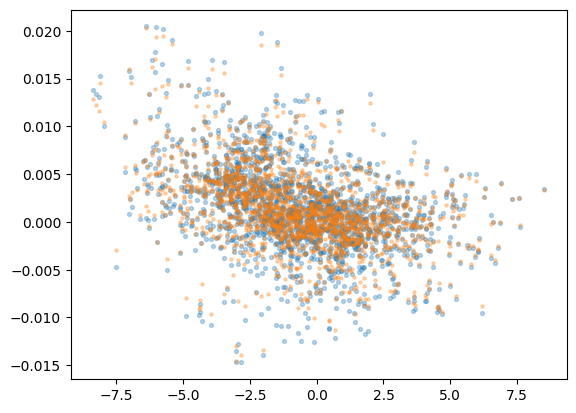

In [19]:
plt.scatter(X_test['V26'][0:2000],y_test['Slope'][0:2000],s=8,alpha=0.3,label="Observations")
plt.scatter(X_test['V26'][0:2000],Pred_test[0:2000],s=5,alpha=0.3,label="Model")

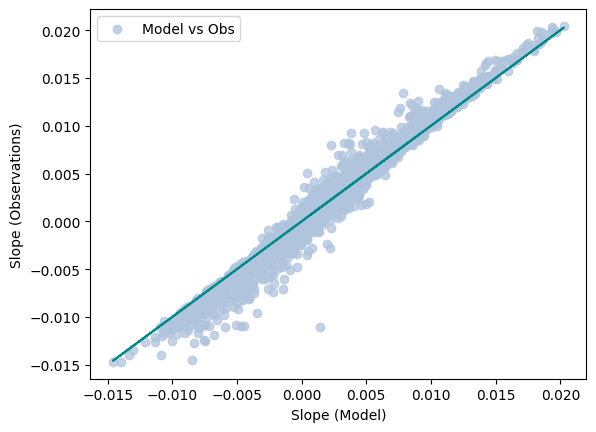

In [20]:
plt.scatter(Pred_test,y_test, color = 'lightsteelblue', alpha = 0.75, label = 'Model vs Obs')
plt.plot(Pred_test,Pred_test, color = 'darkcyan')
plt.ylabel('Slope (Observations)')
plt.xlabel('Slope (Model)')
plt.legend()

# Prediction!

In [119]:
### Where is the test case? 2017-03-15 to 2017-05-15
slope = pd.read_csv(path+'Slopes_data_'+latitud+'_'+longitud+'_ERA5.csv', parse_dates = True, index_col = 0)
data = pd.read_csv(path+'Data_to_train.csv', parse_dates = True, index_col = 0)
dates = [d.strftime('%Y-%m-%d') for d in pd.date_range('2017-03-15','2017-05-15', freq='3d')]
dat_p = data.loc['2017-03-15':'2017-05-15']
slo_p = slope.loc['2017-03-15':'2017-05-15']
Xvals = dat_p[0:int(len(dat_p)*1)][['SST','IQR','TCWV','LW','W0','W1','W7','U0','U1','U4','U7','U11','U14','U26',
                                    'V0','V1','V4','V7','V9','V12','V14','V26']].values
pred = NN_model.predict(Xvals) 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


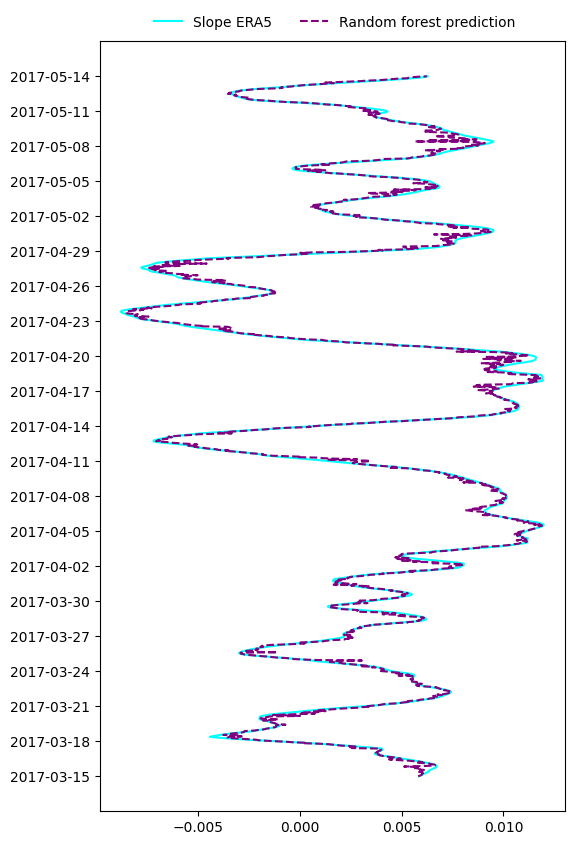

In [121]:
plt.figure(figsize = (6,10))
plt.plot(slo_p['Slope'][0:60*24].values,np.linspace(0,60,len(pred[0:60*24])), label = 'Slope ERA5', color = 'cyan')
plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Random forest prediction', color = 'purple', linestyle = '--')
plt.legend(frameon=False, bbox_to_anchor = (0.92,1.05), ncol=2)
plt.yticks(np.arange(0,61,3), labels = dates)
plt.show()

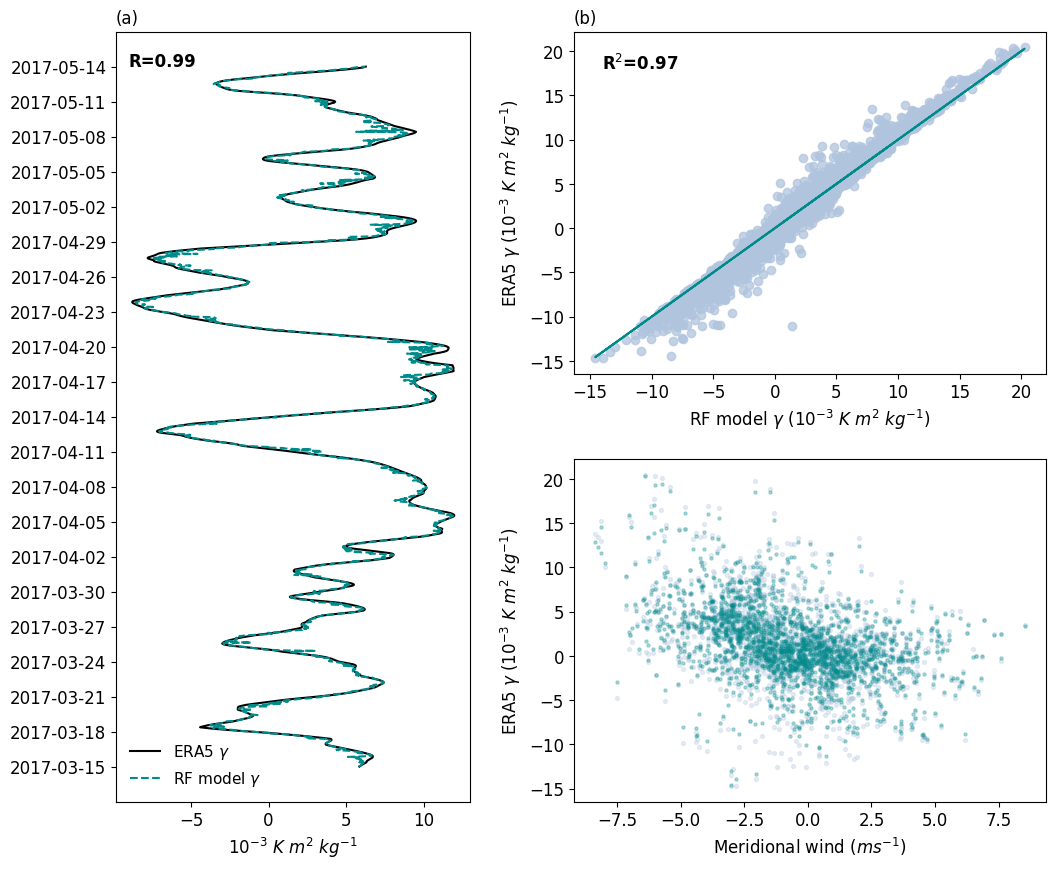

In [122]:
fig = plt.figure(figsize=(12, 10))
gs  = gridspec.GridSpec(nrows=2, ncols=2, width_ratios=[0.75, 1], wspace=0.25, hspace = 0.25)

ax = plt.subplot(gs[:,0])
plt.plot(slo_p['Slope'][0:60*24].values*1000,np.linspace(0,60,len(pred[0:60*24])), label = 'ERA5 $\gamma$', 
         color = 'k')
plt.plot(pred[0:60*24]*1000,np.linspace(0,60,len(pred[0:60*24])), label = 'RF model $\gamma$', color = 'darkcyan', 
         linestyle = '--')

plt.text(-9,60, 'R=0.99', fontweight = 'bold', fontsize = 12)
plt.legend(frameon=False, loc = 'lower left', fontsize = 11)
plt.yticks(np.arange(0,61,3), labels = dates, fontsize = 12)
plt.xlabel('10$^{-3}$ $K$ $m^2$ $kg^{-1}$', fontsize = 12)
plt.xticks(fontsize = 12)
plt.title('(a)', loc = 'left', fontsize = 12)

ax = plt.subplot(gs[0,1])
plt.scatter(Pred_test*1000,y_test*1000, color = 'lightsteelblue', alpha = 0.75, label = 'Model vs Obs')
plt.plot(Pred_test*1000,Pred_test*1000, color = 'darkcyan')
plt.ylabel('ERA5 $\gamma$ (10$^{-3}$ $K$ $m^2$ $kg^{-1}$)', fontsize = 12)
plt.xlabel('RF model $\gamma$ (10$^{-3}$ $K$ $m^2$ $kg^{-1}$)', fontsize = 12)
plt.title('(b)', loc = 'left', fontsize = 12)
plt.text(-14,18, 'R$^2$=0.97', fontweight = 'bold', fontsize = 12)
plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)
#plt.legend()

ax = plt.subplot(gs[1,1])
plt.scatter(X_test['V26'][0:2000],y_test['Slope'][0:2000]*1000,s=8,alpha=0.3,label="ERA5 $\gamma$", 
            color = 'lightsteelblue')
plt.scatter(X_test['V26'][0:2000],Pred_test[0:2000]*1000,s=5,alpha=0.3,label="RF model $\gamma$", 
            color = 'darkcyan')
plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)
plt.ylabel('ERA5 $\gamma$ (10$^{-3}$ $K$ $m^2$ $kg^{-1}$)', fontsize = 12)
plt.xlabel('Meridional wind ($m s^{-1}$)', fontsize = 12)
plt.savefig(f"{path}Figure_S1.pdf", bbox_inches = 'tight', dpi = 300)


# Experiments!

In [23]:
###
# Moisture advection
# Moisture structures
# Total wind
# Zonal wind
# Meridional wind
# No-Meridional shear
# No-Zonal shear
# No shear
# No-Meridional low troposphere shear
# No-Meridional mid and high troposphere shear
# No-Zonal low troposphere shear
# No-Zonal mid and high troposphere shear

In [221]:
### Remember that level 26 is the surface and level 0 is the heighest one!
replaces = [
            ['TCWV','U0','U1','U4','U7','U11','U14','U26','V0','V1','V4','V7','V9','V12','V14','V26'],
            ['IQR','TCWV','V26'],
            ['U0','U1','U4','U7','U11','U14','U26','V0','V1','V4','V7','V9','V12','V14','V26'],
            ['U0','U1','U4','U7','U11','U14','U26'], 
            ['V0','V1','V4','V7','V9','V12','V14','V26'], 
            ['V0','V1','V4','V7','V9','V12','V14','V26'],
            ['V12','V14','V26'],
            ['V0','V1','V4','V7','V9'],
            ['U0','U1','U4','U7','U11','U14','U26'],
            ['U11','U14','U26'], 
            ['U0','U1','U4','U7'],
            ['U0','U1','U4','U7','U11','U14','U26','V0','V1','V4','V7','V9','V12','V14','V26']
            ]
april_12 = np.ones((60*24,len(replaces)))
march_20 = np.ones((60*24,len(replaces)))
var1 = [None,None,None,None,None,'V26','V26','V9','U26','U26','U7','U26']
var2 = [None,None,None,None,None,None,None,None,None,None,None,'V26']
for i,replace in enumerate(replaces):
        april_12[:,i] = experiments(replace,'2017-04-12 16:00:00',var1[i],var2[i])[0:60*24]
        march_20[:,i] = experiments(replace,'2017-04-05 06:00:00',var1[i],var2[i])[0:60*24]
    #'2017-04-05 06:00:00' this date works also to produce organization
    #'2017-03-21 12:00:00' 

/var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/3472137856.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat[i] = apr12[i]
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/3472137856.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat[i] = apr12[i]
/opt/anaconda3/lib/python3.11/

/var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/3472137856.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat[i] = apr12[var1]
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_44173/3472137856.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat[i] = apr12[var1]
/opt/anaconda3/lib/pytho

### Lets plot them all

In [186]:
from matplotlib.gridspec import GridSpec
from pylab import *

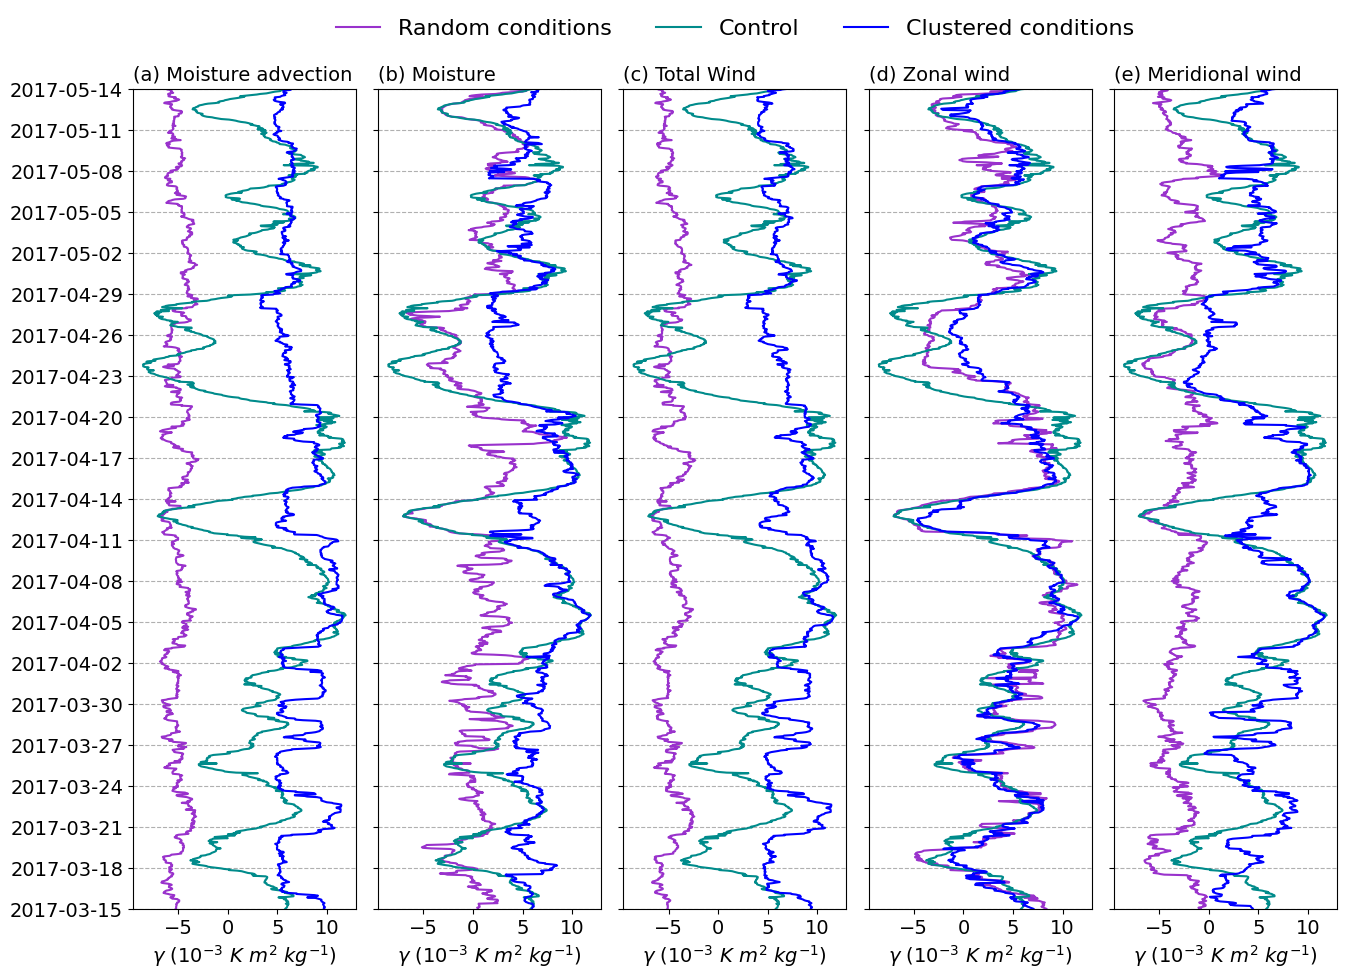

In [219]:
fig = plt.figure(figsize=(14,10))
gs = GridSpec(1,5,left = 0.09, right = 0.95, hspace=0, wspace=0.1, top = 0.9, bottom = 0.08)
title = ['(a) Moisture advection','(b) Moisture','(c) Total Wind','(d) Zonal wind','(e) Meridional wind']

for i in range(5):
    ax = plt.subplot(gs[i])
    plt.plot(april_12[:,i]*1000,np.linspace(0,60,len(april_12[:,i])), label = 'Random conditions', color = 'darkorchid')
    plt.plot(pred[0:60*24]*1000,np.linspace(0,60,len(pred[0:60*24])), label = 'Control', color = 'darkcyan')
    plt.plot(march_20[:,i]*1000,np.linspace(0,60,len(march_20[:,i])), label = 'Clustered conditions', color = 'blue')
    plt.title(title[i],  fontsize = 14, loc = 'left')
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('$\gamma$ (10$^{-3}$ $K$ $m^2$ $kg^{-1}$)',  fontsize = 14)
    #plt.xticks(np.arange(-0.01,0.011,0.01))
    #plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    if i == 0:
        plt.yticks(np.arange(0,61,3), labels = dates)
    else:
        plt.yticks(np.arange(0,61,3))
        ax.yaxis.set_major_formatter(NullFormatter())
    if i == 2:
        plt.legend(ncol=3, frameon=False, bbox_to_anchor=(0.5,1.11), fontsize = 16, loc='upper center') #0.5,1.09
plt.savefig(path+'Exp_moist_wind.jpg', bbox_inches='tight', dpi = 300)
plt.savefig(path+'Exp_moist_wind.pdf', bbox_inches='tight', dpi = 300)

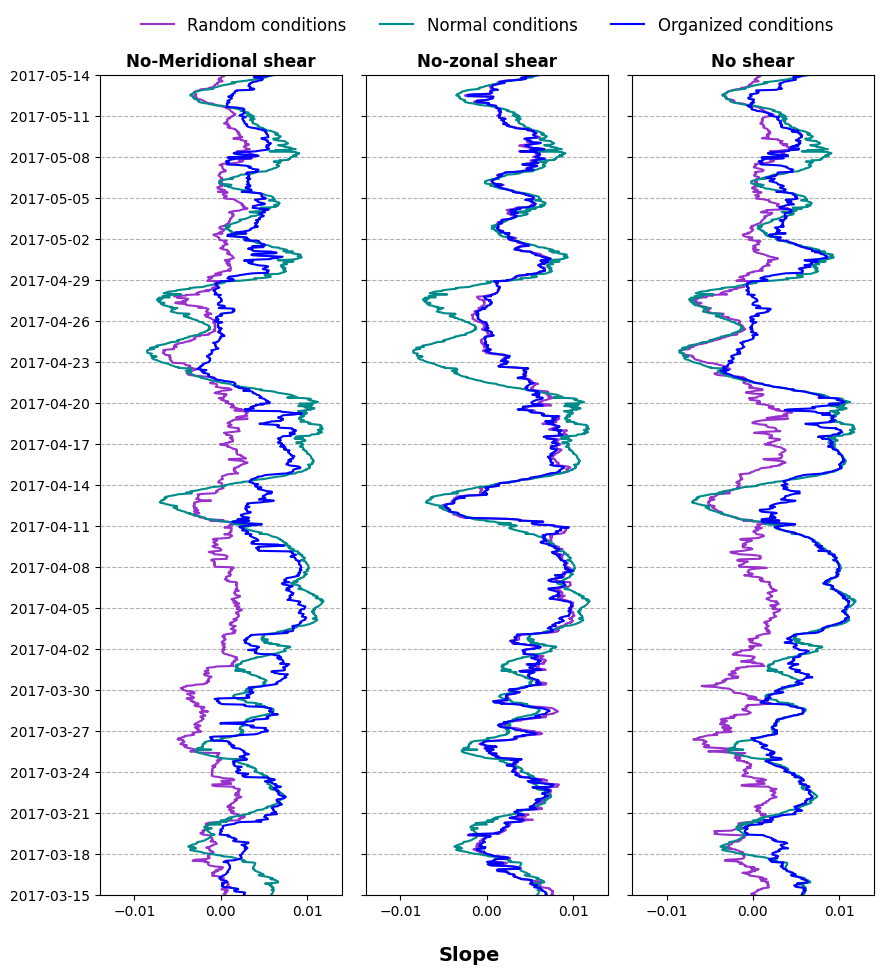

In [214]:
fig = plt.figure(figsize=(9,10))
gs = GridSpec(1,3,left = 0.09, right = 0.95, hspace=0, wspace=0.1, top = 0.9, bottom = 0.08)
titles = ['No-Meridional shear', 'No-zonal shear', 'No shear']

for i,title in enumerate(titles):
    ax = plt.subplot(gs[i])
    plt.plot(april_12[:,i+5],np.linspace(0,60,len(april_12[:,i+5])), label = 'Random conditions', 
             color = 'darkorchid')
    plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Normal conditions', color = 'darkcyan')
    plt.plot(march_20[:,i+5],np.linspace(0,60,len(march_20[:,i+5])), label = 'Organized conditions', 
             color = 'blue')
    plt.title(title, fontweight = 'bold')
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    fig.supxlabel('Slope', fontweight = 'bold', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    if i == 0:
        plt.yticks(np.arange(0,61,3), labels = dates)
    else:
        plt.yticks(np.arange(0,61,3))
        ax.yaxis.set_major_formatter(NullFormatter())
    if i == 1:
        plt.legend(ncol=3, frameon=False, bbox_to_anchor=(0.5,1.09), fontsize = 12, loc='upper center')
plt.savefig(path+'Exp_shear.jpg', bbox_inches='tight')

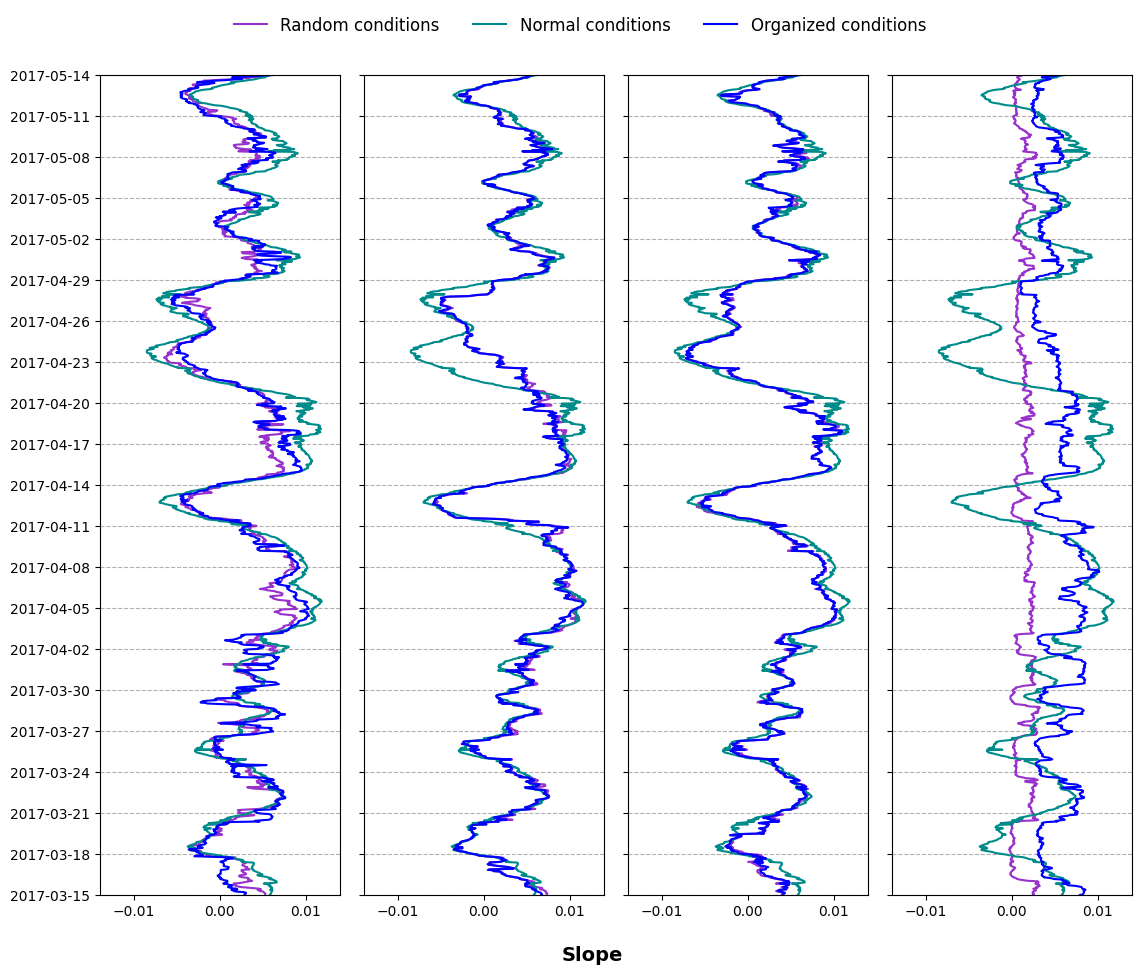

In [213]:
fig = plt.figure(figsize=(12,10))
gs = GridSpec(1,4,left = 0.09, right = 0.95, hspace=0, wspace=0.1, top = 0.9, bottom = 0.08)
titles = ['No-Meridional low trop shear', 'No-Meridional high trop shear', 
          'No-Zonal low trop shear', 'No-Zonal high trop shear']

for i,title in enumerate(titles):
    ax = plt.subplot(gs[i])
    plt.plot(april_12[:,i+8],np.linspace(0,60,len(april_12[:,i+8])), label = 'Random conditions', 
             color = 'darkorchid')
    plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Normal conditions', color = 'darkcyan')
    plt.plot(march_20[:,i+8],np.linspace(0,60,len(march_20[:,i+8])), label = 'Organized conditions', 
             color = 'blue')
    #plt.title(title, fontweight = 'bold', fontsize = 10)
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    fig.supxlabel('Slope', fontweight = 'bold', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,55)
    if i == 0:
        plt.yticks(np.arange(0,61,3), labels = dates)
    else:
        plt.yticks(np.arange(0,61,3))
        ax.yaxis.set_major_formatter(NullFormatter())
    if i == 1:
        plt.legend(ncol=3, frameon=False, bbox_to_anchor=(0.9,1.09), fontsize = 12, loc='upper center')
#plt.savefig(path+'Exp_shear_2.jpg', bbox_inches='tight')

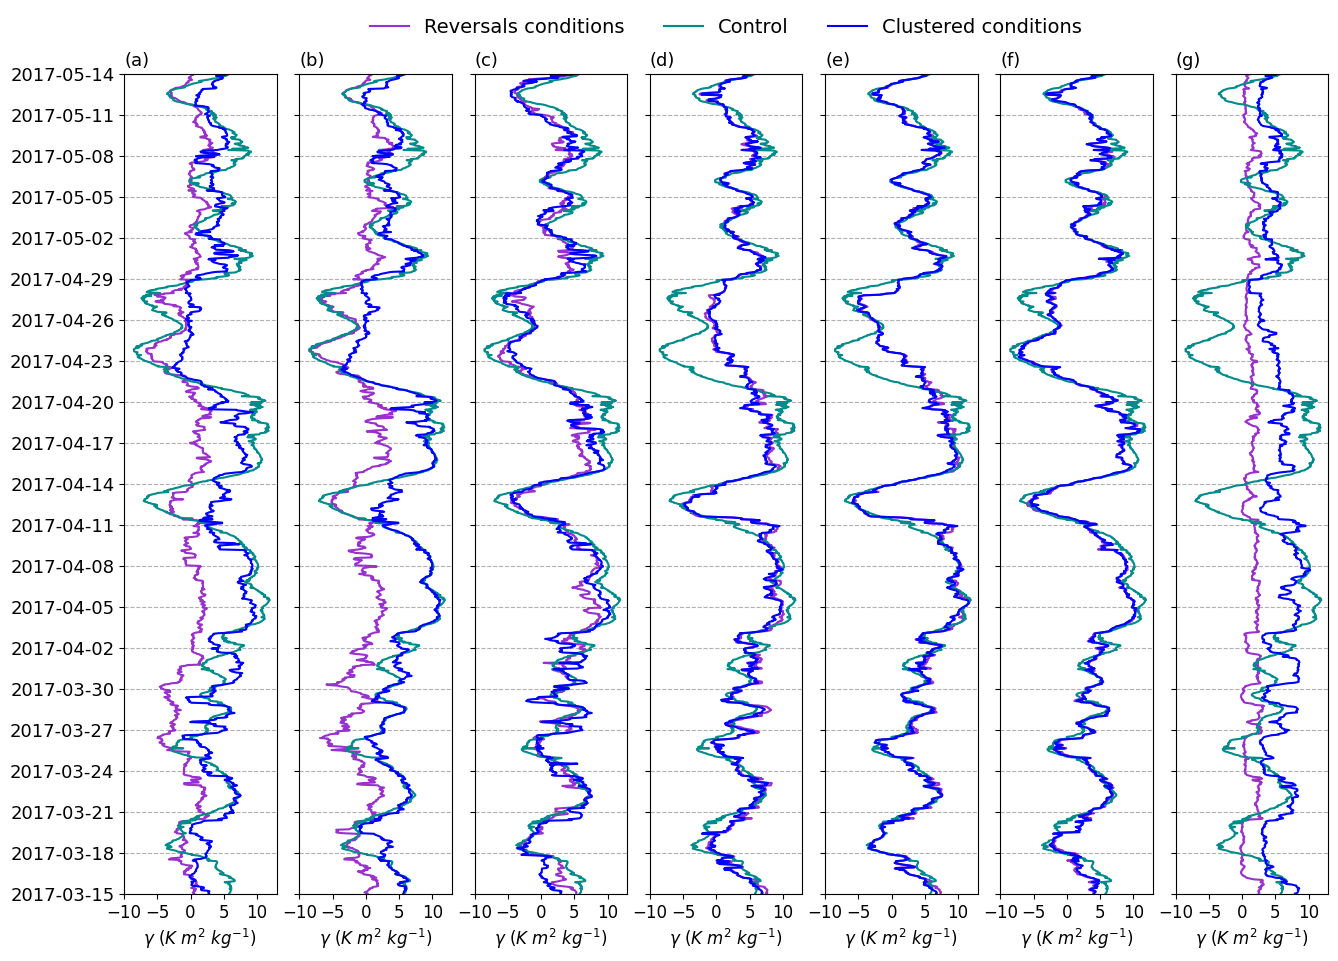

In [232]:
fig = plt.figure(figsize=(14,10))
gs = GridSpec(1,7,left = 0.09, right = 0.95, hspace=0, wspace=0.15, top = 0.9, bottom = 0.08)
titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']

for i,title in enumerate(titles):
    ax = plt.subplot(gs[i])
    plt.plot(april_12[:,i+5]*1000,np.linspace(0,60,len(april_12[:,i+5])), label = 'Reversals conditions', 
             color = 'darkorchid')
    plt.plot(pred[0:60*24]*1000,np.linspace(0,60,len(pred[0:60*24])), label = 'Control', color = 'darkcyan')
    plt.plot(march_20[:,i+5]*1000,np.linspace(0,60,len(march_20[:,i+5])), label = 'Clustered conditions', 
             color = 'blue')
    plt.title(title, fontsize = 13, loc = 'left')
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('$\gamma$ ($K$ $m^2$ $kg^{-1}$)', fontsize = 12)
    plt.xticks(np.arange(-10,10.1,5), fontsize = 12)
    plt.yticks(fontsize = 13)
    plt.ylim(0,60)
    if i == 0:
        plt.yticks(np.arange(0,61,3), labels = dates)
    else:
        plt.yticks(np.arange(0,61,3))
        ax.yaxis.set_major_formatter(NullFormatter())
    if i == 3:
        plt.legend(ncol=3, frameon=False, bbox_to_anchor=(0.5,1.09), fontsize = 14, loc='upper center')
plt.savefig(path+'Exp_shear_Complete.pdf', bbox_inches='tight')

# Now two questions to answer
## Why the reversals happen
## Why the convection is organized

### Experiments for reversals first!

In [191]:
data = pd.read_csv(path+'Data_to_train.csv', parse_dates = True, index_col = 0)
dat_p = data.loc['2017-03-15':'2017-05-15']
dat = dat_p
### Lets try to produce only reversals and only organise convection
apr12 = dat_p.loc['2017-04-12 16:00:00']
mar20 = dat_p.loc['2017-04-05 06:00:00']

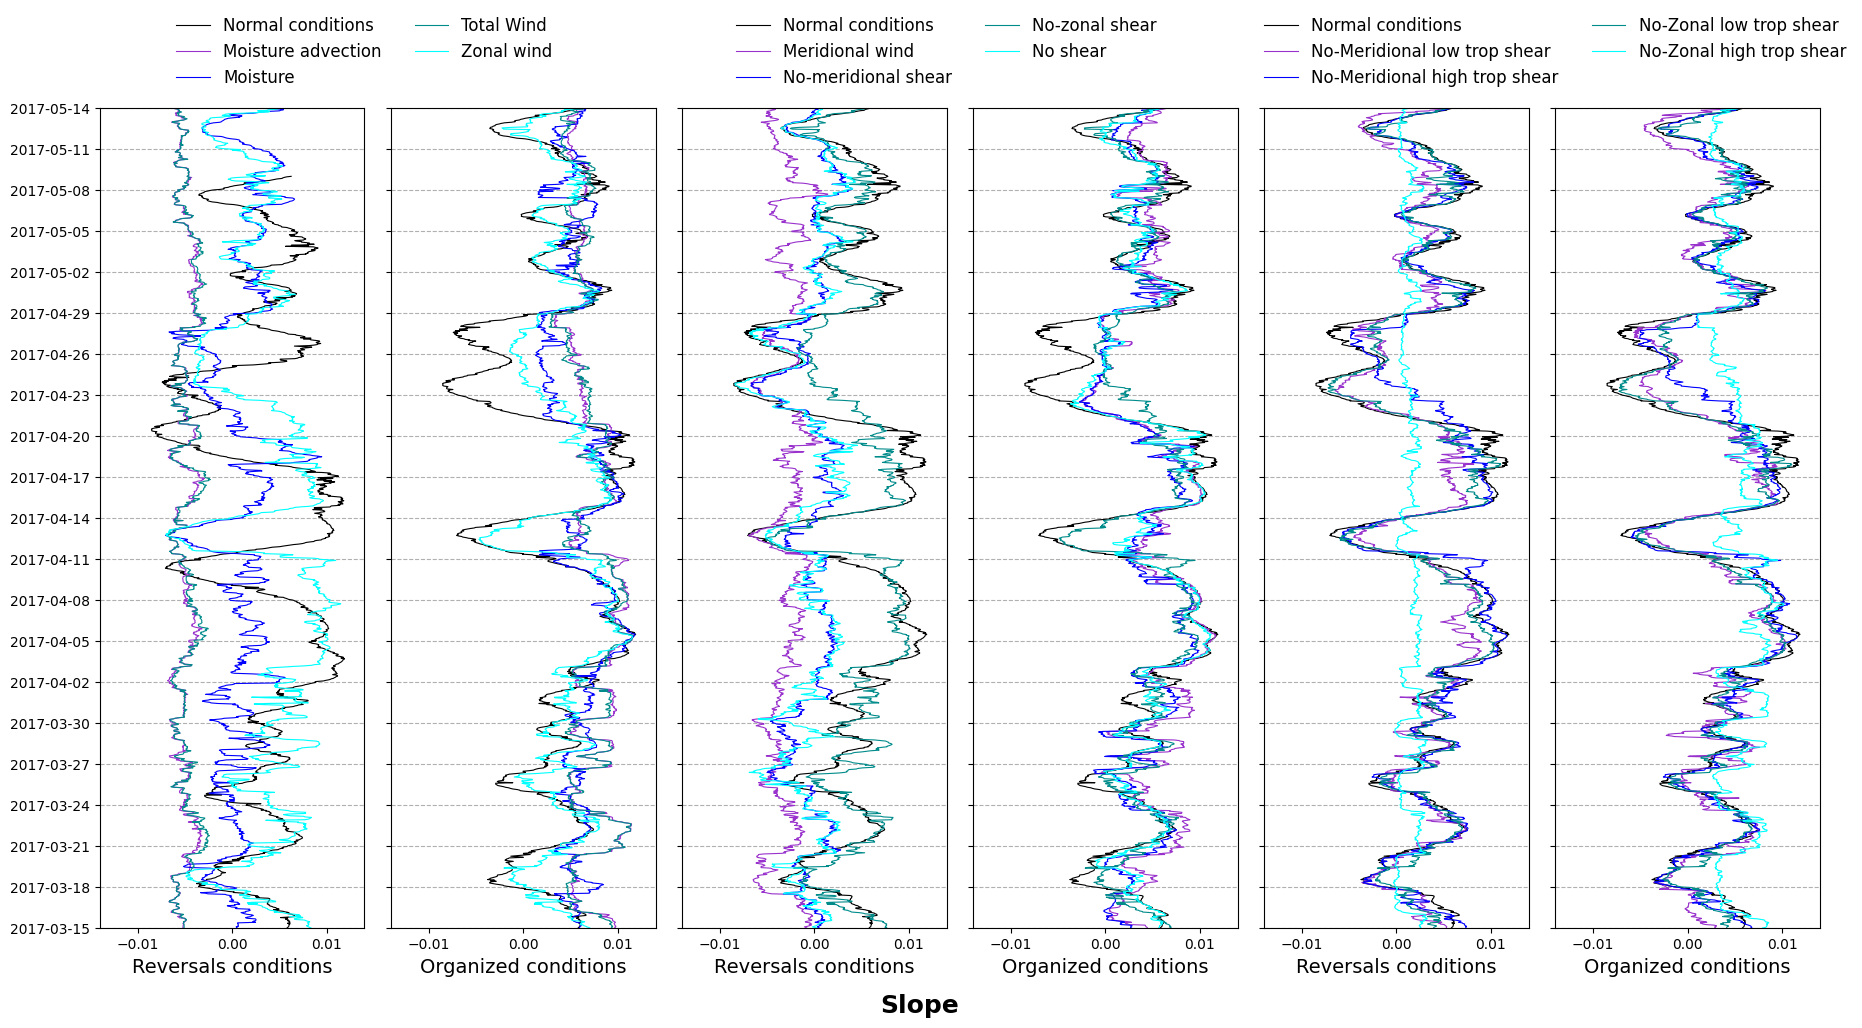

In [194]:
fig = plt.figure(figsize=(20,10))
c = ['darkorchid','blue','darkcyan','cyan','red']
labels = ['Moisture advection','Moisture','Total Wind','Zonal wind','Meridional wind','No-meridional shear',
          'No-zonal shear', 'No shear','No-Meridional low trop shear', 'No-Meridional high trop shear', 
          'No-Zonal low trop shear', 'No-Zonal high trop shear']

gs = GridSpec(1,6,left = 0.09, right = 0.95, hspace=0.1, wspace=0.1, top = 0.9, bottom = 0.08)
ax = plt.subplot(gs[0])
plt.plot(pred[0:60*24],np.linspace(0,55,len(pred[0:60*24])), label = 'Normal conditions', color = 'k',
         linewidth = 0.8)
fig.supxlabel('Slope', fontweight = 'bold', fontsize = 18, y = -0.01)
for i in range(4):
    plt.plot(april_12[:,i],np.linspace(0,60,len(april_12[:,i])), label = labels[i], color = c[i], 
             linewidth = 0.8)
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('Reversals conditions', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    plt.yticks(np.arange(0,61,3), labels = dates)
    plt.legend(ncol=2, frameon=False, bbox_to_anchor=(1.0,1.13), fontsize = 12, loc='upper center')

ax = plt.subplot(gs[1])
plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Normal conditions', color = 'k',
         linewidth = 0.8)
for i in range(4):
    plt.plot(march_20[:,i],np.linspace(0,60,len(march_20[:,i])), label = labels[i], color = c[i], 
             linewidth = 0.8)    
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('Organized conditions', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    plt.yticks(np.arange(0,61,3), labels = dates)
    ax.yaxis.set_major_formatter(NullFormatter())

#c = ['green','red','orange','grey']
ax = plt.subplot(gs[2])
plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Normal conditions', color = 'k',
         linewidth = 0.8)
for i in range(4):
    plt.plot(april_12[:,i+4],np.linspace(0,60,len(april_12[:,i+4])), label = labels[i+4], color = c[i], 
             linewidth = 0.8)
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('Reversals conditions', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    plt.yticks(np.arange(0,61,3), labels = dates)
    ax.yaxis.set_major_formatter(NullFormatter())
    plt.legend(ncol=2, frameon=False, bbox_to_anchor=(1.0,1.13), fontsize = 12, loc='upper center')
    
ax = plt.subplot(gs[3])
plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Normal conditions', color = 'k',
         linewidth = 0.8)
for i in range(4):
    plt.plot(march_20[:,i+4],np.linspace(0,60,len(march_20[:,i+4])), label = labels[i+4], color = c[i], 
             linewidth = 0.8)
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('Organized conditions', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    plt.yticks(np.arange(0,61,3), labels = dates)
    ax.yaxis.set_major_formatter(NullFormatter())
    
ax = plt.subplot(gs[4])
plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Normal conditions', color = 'k',
         linewidth = 0.8)
for i in range(4):
    plt.plot(april_12[:,i+8],np.linspace(0,60,len(april_12[:,i+8])), label = labels[i+8], color = c[i], 
             linewidth = 0.8)
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('Reversals conditions', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    plt.yticks(np.arange(0,61,3), labels = dates)
    ax.yaxis.set_major_formatter(NullFormatter())
    plt.legend(ncol=2, frameon=False, bbox_to_anchor=(1.1,1.13), fontsize = 12, loc='upper center')
    
ax = plt.subplot(gs[5])
plt.plot(pred[0:60*24],np.linspace(0,60,len(pred[0:60*24])), label = 'Normal conditions', color = 'k',
         linewidth = 0.8)
for i in range(4):
    plt.plot(march_20[:,i+8],np.linspace(0,60,len(march_20[:,i+8])), label = labels[i+8], color = c[i], 
             linewidth = 0.8)
    plt.grid(linestyle='--', linewidth = 0.8, axis = 'y')
    plt.xlabel('Organized conditions', fontsize = 14)
    plt.xticks(np.arange(-0.01,0.011,0.01))
    plt.xlim(-0.014,0.014)
    plt.ylim(0,60)
    plt.yticks(np.arange(0,61,3), labels = dates)
    ax.yaxis.set_major_formatter(NullFormatter())


# This is a type of index!

(0.0, 5.5)

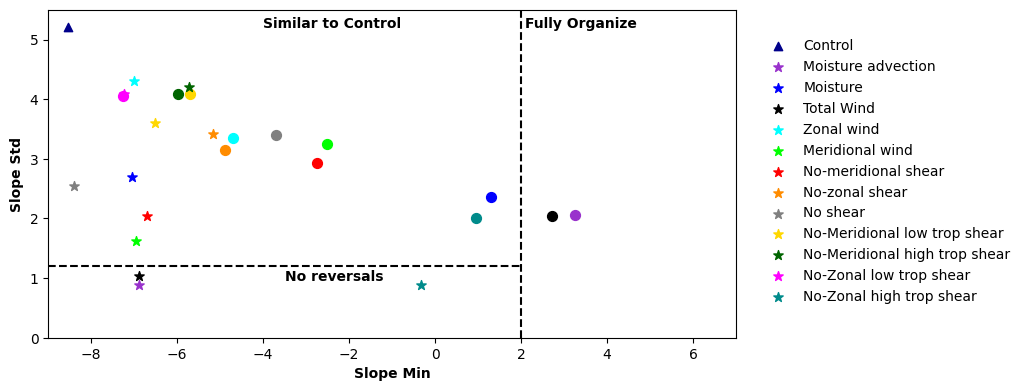

In [195]:
### First experiments
labels = ['Moisture advection','Moisture','Total Wind','Zonal wind','Meridional wind','No-meridional shear',
          'No-zonal shear', 'No shear','No-Meridional low trop shear', 'No-Meridional high trop shear', 
          'No-Zonal low trop shear', 'No-Zonal high trop shear']
c = ['darkorchid','blue','k','cyan','lime','red','darkorange','grey','gold','darkgreen','magenta','darkcyan']

apr_max = np.min(april_12[:,:], axis = 0)*1000
mar_max = np.min(march_20[:,:], axis = 0)*1000
apr_std = np.std(april_12[:,:], axis = 0)*1000
mar_std = np.std(march_20[:,:], axis = 0)*1000

plt.figure(figsize=(8,4))
gs = GridSpec(1,1,left = 0.09, right = 0.95, hspace=0.2, wspace=0, top = 0.9, bottom = 0.08)
ax = plt.subplot(gs[0])

plt.scatter(np.min(pred[0:55*24])*1000,(np.std(pred[0:55*24])*1000), marker = '^', color = 'darkblue', 
            label = 'Control')
for i,x in enumerate(labels):
    plt.scatter(apr_max[i], apr_std[i], color = c[i], label = x, marker = '*', s = 50)
    plt.scatter(mar_max[i], mar_std[i], color = c[i], s = 50)#, label = x)

plt.legend(bbox_to_anchor=(1.22,0.95), ncol=1, frameon=False, loc='upper center')
plt.plot(np.arange(-9,2.1),np.ones(12)*1.2, linestyle='--', color = 'k')
plt.text(-3.5,0.95,'No reversals', fontweight = 'bold')
plt.axvline(2, linestyle='--', color = 'k')
plt.text(2.1,5.2,'Fully Organize', fontweight = 'bold')
plt.text(-4,5.2,'Similar to Control', fontweight = 'bold')
plt.xlabel('Slope Min', fontweight = 'bold')
plt.ylabel('Slope Std', fontweight = 'bold')
plt.xlim(-9,7)
plt.ylim(0,5.5)

In [224]:
import scipy.stats as stats
spea_20 = []
spea_12 = []
for i in range(len(labels)):
    z = stats.pearsonr(april_12[:,i],pred[0:60*24])[0]
    spea_12.append(z)
    z = stats.pearsonr(march_20[:,i],pred[0:60*24])[0]
    spea_20.append(z)

In [225]:
iqr_20 = []
iqr_12 = []
quas = 95
quae = 5
for i in range(len(labels)):
    iqr_12.append(np.percentile(april_12[:,i],quas) - np.percentile(april_12[:,i],quae))
    iqr_20.append(np.percentile(march_20[:,i],quas) - np.percentile(march_20[:,i],quae))

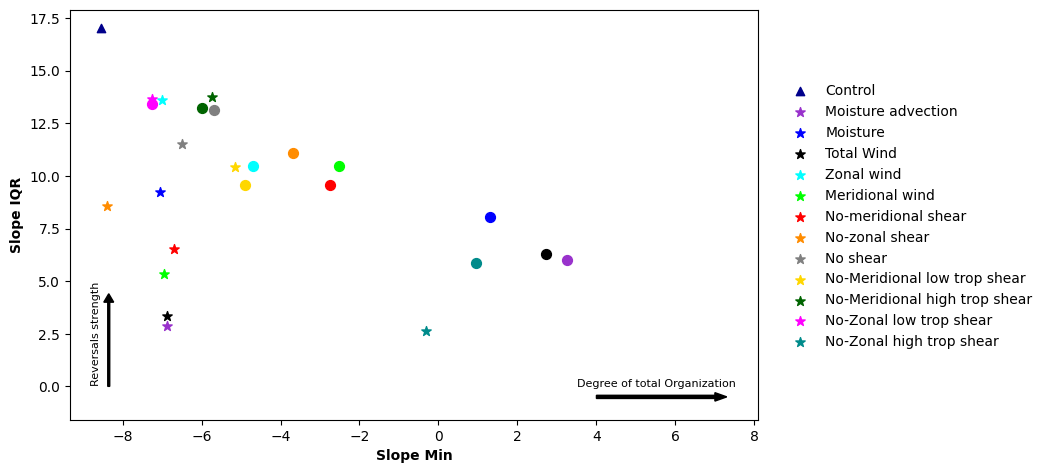

In [226]:
### First experiments
labels = ['Moisture advection','Moisture','Total Wind','Zonal wind','Meridional wind','No-meridional shear',
          'No-zonal shear', 'No shear','No-Meridional low trop shear', 'No-Meridional high trop shear', 
          'No-Zonal low trop shear', 'No-Zonal high trop shear']
c = ['darkorchid','blue','k','cyan','lime','red','darkorange','grey','gold','darkgreen','magenta','darkcyan']

apr_min = np.min(april_12[:,:], axis = 0)*1000
mar_min = np.min(march_20[:,:], axis = 0)*1000

apr_iqr = iqr_12
mar_iqr = iqr_20

plt.figure(figsize=(8,5))
gs = GridSpec(1,1,left = 0.09, right = 0.95, hspace=0.2, wspace=0, top = 0.9, bottom = 0.08)
ax = plt.subplot(gs[0])

plt.scatter(np.min(pred[0:55*24])*1000,(np.percentile(pred[0:55*24],quas)-np.percentile(pred[0:55*24],quae))*1000,
            marker = '^', color = 'darkblue', label = 'Control')
for i,x in enumerate(labels):
    plt.scatter(apr_min[i], apr_iqr[i]*1000, color = c[i], label = x, marker = '*', s = 50)
    plt.scatter(mar_min[i], mar_iqr[i]*1000, color = c[i], s = 50)#, label = 'Random '+x)

plt.legend(bbox_to_anchor=(1.22,0.85), ncol=1, frameon=False, loc='upper center')
plt.arrow(-8.35,0,0,4, width=0.05, head_width = 0.25, head_length = 0.4, color = 'k')
plt.text(-8.8,0.12,'Reversals strength', rotation = 90, fontsize = 8)
plt.arrow(4,-0.5,3,0, width=0.15, head_width = 0.4, head_length = 0.3, color = 'k')
plt.text(3.5,0,'Degree of total Organization', fontsize = 8)
plt.xlabel('Slope Min', fontweight = 'bold')
plt.ylabel('Slope IQR', fontweight = 'bold')
#plt.xlim(-9,7)
plt.show()

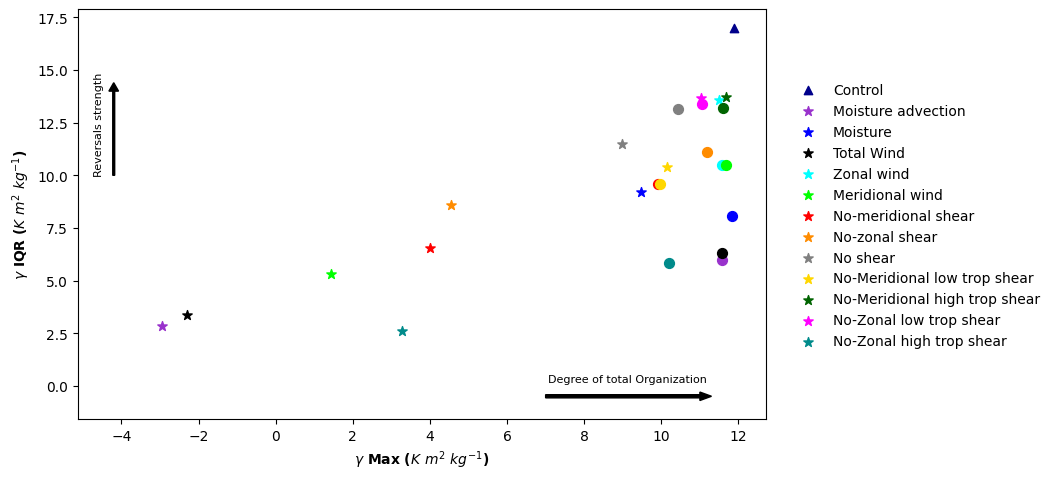

In [227]:
### First experiments
labels = ['Moisture advection','Moisture','Total Wind','Zonal wind','Meridional wind','No-meridional shear',
          'No-zonal shear', 'No shear','No-Meridional low trop shear', 'No-Meridional high trop shear', 
          'No-Zonal low trop shear', 'No-Zonal high trop shear']
c = ['darkorchid','blue','k','cyan','lime','red','darkorange','grey','gold','darkgreen','magenta','darkcyan']

apr_max = np.max(april_12[:,:], axis = 0)*1000
mar_max = np.max(march_20[:,:], axis = 0)*1000

apr_iqr = iqr_12
mar_iqr = iqr_20

plt.figure(figsize=(8,5))
gs = GridSpec(1,1,left = 0.09, right = 0.95, hspace=0.2, wspace=0, top = 0.9, bottom = 0.08)
ax = plt.subplot(gs[0])

plt.scatter(np.max(pred[0:55*24])*1000,(np.percentile(pred[0:55*24],quas)-np.percentile(pred[0:55*24],quae))*1000,
            marker = '^', color = 'darkblue', label = 'Control')
for i,x in enumerate(labels):
    plt.scatter(apr_max[i], apr_iqr[i]*1000, color = c[i], label = x, marker = '*', s = 50)
    plt.scatter(mar_max[i], mar_iqr[i]*1000, color = c[i], s = 50)

plt.legend(bbox_to_anchor=(1.22,0.85), ncol=1, frameon=False, loc='upper center')
plt.arrow(-4.2,10,0,4, width=0.05, head_width = 0.25, head_length = 0.4, color = 'k')
plt.text(-4.7,10.05,'Reversals strength', rotation = 90, fontsize = 8)
plt.arrow(7,-0.5,4,0, width=0.15, head_width = 0.4, head_length = 0.3, color = 'k')
plt.text(7.05,0.15,'Degree of total Organization', fontsize = 8)
plt.xlabel('$\gamma$ Max ($K$ $m^2$ $kg^{-1}$)', fontweight = 'bold')
plt.ylabel('$\gamma$ IQR ($K$ $m^2$ $kg^{-1}$)', fontweight = 'bold')
#plt.xlim(-9,7)
plt.show()

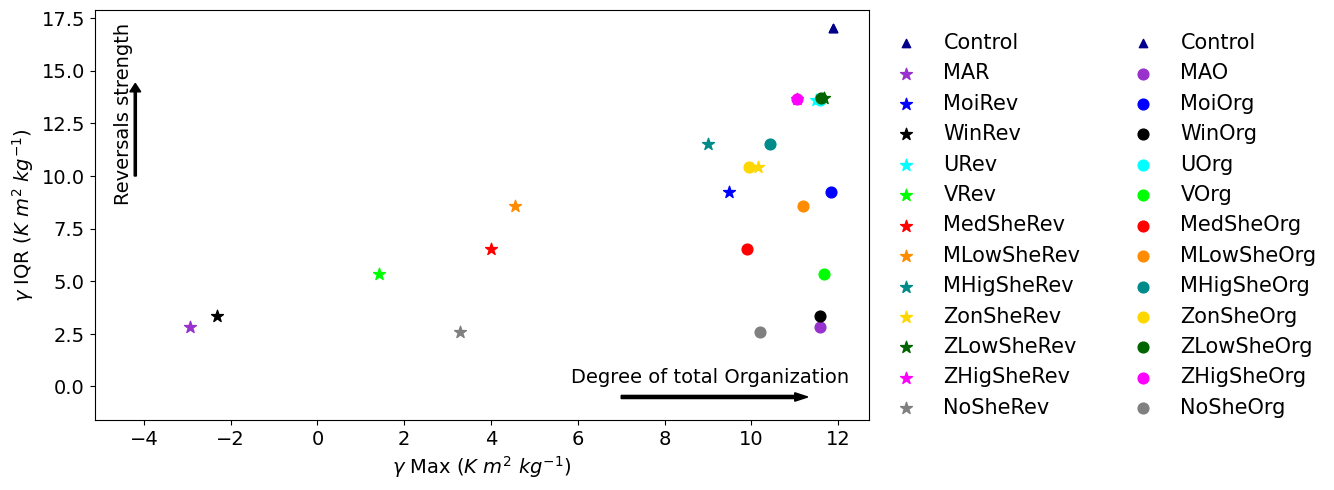

In [233]:
### First experiments
label_rev = ['MAR','MoiRev','WinRev','URev','VRev','MedSheRev','MLowSheRev','MHigSheRev',
             'ZonSheRev','ZLowSheRev', 'ZHigSheRev','NoSheRev']

label_org = ['MAO','MoiOrg','WinOrg','UOrg','VOrg','MedSheOrg','MLowSheOrg', 'MHigSheOrg',
             'ZonSheOrg','ZLowSheOrg', 'ZHigSheOrg','NoSheOrg']

c = ['darkorchid','blue','k','cyan','lime','red','darkorange','darkcyan','gold','darkgreen','magenta','grey']

apr_max = np.max(april_12[:,:], axis = 0)*1000
mar_max = np.max(march_20[:,:], axis = 0)*1000

apr_iqr = iqr_12
mar_iqr = iqr_20

plt.figure(figsize=(9,5))
gs = GridSpec(1,1,left = 0.09, right = 0.95, hspace=0.2, wspace=0, top = 0.9, bottom = 0.08)
ax = plt.subplot(gs[0])

plt.scatter(np.max(pred[0:55*24])*1000,(np.percentile(pred[0:55*24],quas)-np.percentile(pred[0:55*24],quae))*1000,
            marker = '^', color = 'darkblue', label = 'Control')
for i,x in enumerate(label_rev):
    plt.scatter(apr_max[i], apr_iqr[i]*1000, color = c[i], label = x, marker = '*', s = 80)

plt.scatter(np.max(pred[0:55*24])*1000,(np.percentile(pred[0:55*24],quas)-np.percentile(pred[0:55*24],quae))*1000,
            marker = '^', color = 'darkblue', label = 'Control')
for i,x in enumerate(label_org):
    plt.scatter(mar_max[i], apr_iqr[i]*1000, color = c[i], label = x, s = 60)

plt.legend(bbox_to_anchor=(1.3,0.99), ncol=2, frameon=False, loc='upper center', fontsize = 15)
plt.arrow(-4.2,10,0,4, width=0.05, head_width = 0.25, head_length = 0.4, color = 'k')
plt.text(-4.7,8.8,'Reversals strength', rotation = 90, fontsize = 14)
plt.arrow(7,-0.5,4,0, width=0.15, head_width = 0.4, head_length = 0.3, color = 'k')
plt.text(5.85,0.15,'Degree of total Organization', fontsize = 14)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlabel('$\gamma$ Max ($K$ $m^2$ $kg^{-1}$)', fontsize = 14)
plt.ylabel('$\gamma$ IQR ($K$ $m^2$ $kg^{-1}$)', fontsize = 14)
#plt.xlim(-9,7)
plt.savefig(path+'Index_all_experiments_legend.jpg', bbox_inches='tight', dpi = 300)
plt.savefig(path+'Index_all_experiments_legend.pdf', bbox_inches='tight', dpi = 300)
plt.show()